In [6]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from pathlib import Path
import random


In [7]:
# --- CONFIGURACIÓN DE RUTAS ---
BASE_DIR = Path("..")

# El modelo maestro
MODELS_DIR = BASE_DIR / "models"
MODEL_PATH = MODELS_DIR / "modelo_residuos_rpi_03.keras"

# Tu carpeta con fotos reales tomadas por ti
IMAGES_TEST_DIR = BASE_DIR / "tests" / "images"

# Definimos las clases exactamente en el mismo orden alfabético que se entrenaron
class_names = ['crushed_metal', 'crushed_plastic', 'metal', 'no_reciclable', 'plastic']

print(f"Buscando imágenes de prueba en: {IMAGES_TEST_DIR.resolve()}")

Buscando imágenes de prueba en: /home/lordaguakate/Documentos/GitHub/EntrenamientoIA/tests/images


In [8]:
print("Cargando el modelo...")
model = tf.keras.models.load_model(MODEL_PATH)
print("✅ Modelo cargado y listo para inferencia.")

Cargando el modelo...
✅ Modelo cargado y listo para inferencia.


In [9]:
def analizar_residuo_real(ruta_imagen):
    # 1. Cargar imagen original solo para visualizarla bonita al final
    img_original = image.load_img(ruta_imagen)
    
    # 2. Cargar y preprocesar la imagen para el modelo
    img_preprocesada = image.load_img(ruta_imagen, target_size=(224, 224))
    img_array = image.img_to_array(img_preprocesada)
    
    # NORMALIZACIÓN: ¡Paso crítico! Si olvidamos esto, la IA verá todo blanco
    img_array = img_array / 255.0  
    
    # Keras espera un "lote" (batch) de imágenes, así que agregamos una dimensión extra
    img_array = np.expand_dims(img_array, axis=0) # Forma final: (1, 224, 224, 3)
    
    # 3. Predicción
    predicciones = model.predict(img_array, verbose=0) # verbose=0 para no saturar la consola
    indice_ganador = np.argmax(predicciones[0])
    porcentaje_confianza = predicciones[0][indice_ganador] * 100
    categoria_predicha = class_names[indice_ganador]
    
    # 4. Mostrar Resultados
    plt.figure(figsize=(6, 6))
    plt.imshow(img_original)
    
    # Si está muy seguro (>80%) el texto será verde, si duda, será naranja
    color_texto = 'green' if porcentaje_confianza > 80 else 'darkorange'
    
    plt.title(f"Predicción: {categoria_predicha.upper()}\nConfianza: {porcentaje_confianza:.2f}%", 
                fontsize=14, color=color_texto, fontweight='bold')
    plt.axis('off')
    plt.show()

📸 ¡Se encontraron 14 fotos en la carpeta de pruebas!

--- Analizando: pruebas (5).jpeg ---


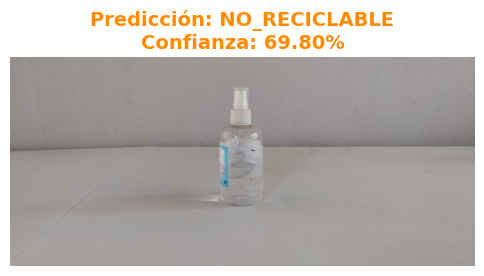


--- Analizando: 20260505_191200_metal_xxxtentationxxx.jpg ---


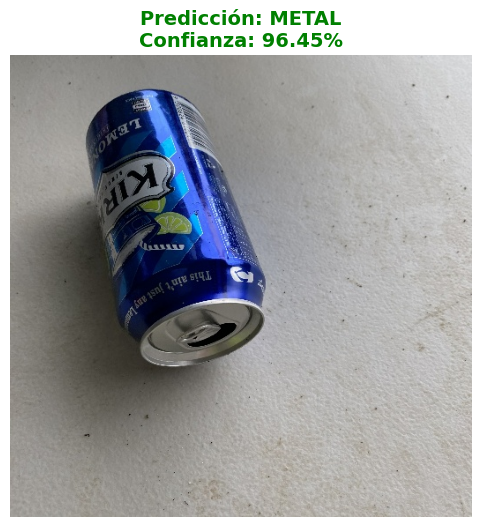


--- Analizando: 20260505_191156_crushed_metal_xxxtentationxxx.jpg ---


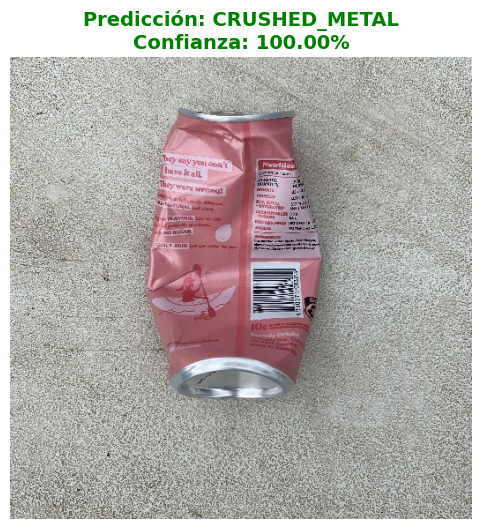


--- Analizando: 20260505_191159_crushed_plastic_xxxtentationxxx.jpg ---


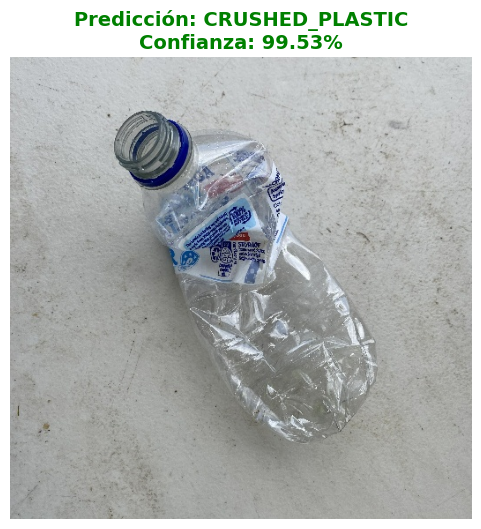


--- Analizando: 20260519_175329_plastic_cristianbroxdoa_20222881.jpg ---


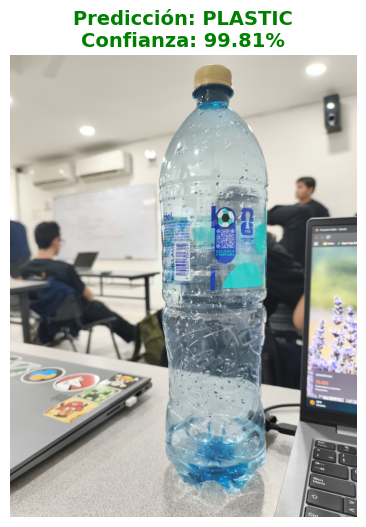


--- Analizando: 20260519_175538_plastic_juarez_cano_alan_yakxel_20222482.jpg ---


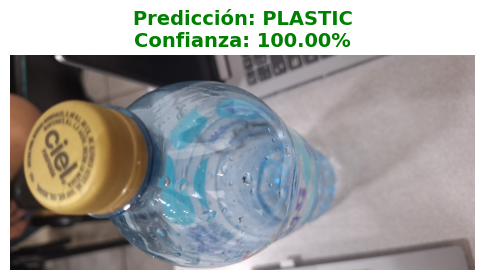

In [10]:
# Verificamos si la carpeta existe
if IMAGES_TEST_DIR.exists():
    # Buscamos todas las imágenes JPG o PNG
    fotos_reales = [f for f in IMAGES_TEST_DIR.iterdir() if f.is_file() and f.suffix.lower() in ['.jpg', '.jpeg', '.png']]
    
    if fotos_reales:
        print(f"📸 ¡Se encontraron {len(fotos_reales)} fotos en la carpeta de pruebas!")
        
        # Elegimos hasta 6 fotos al azar para no saturar la pantalla
        cantidad_a_probar = min(6, len(fotos_reales))
        fotos_seleccionadas = random.sample(fotos_reales, cantidad_a_probar)
        
        for foto in fotos_seleccionadas:
            print(f"\n--- Analizando: {foto.name} ---")
            analizar_residuo_real(foto)
            
    else:
        print("La carpeta tests/images existe, pero está vacía o no tiene imágenes JPG/PNG.")
else:
    print(f"⚠️ No se encontró la ruta {IMAGES_TEST_DIR}.")
    print("Por favor, crea la carpeta y coloca algunas fotos tomadas con tu celular o la cámara web.")